# Luottoriskin pisteytyskortti päätöspuulla (PROC HPSPLIT)

## Tiivistelmä

Tämä muistikirja rakentaa tulkittavan luoton maksukyvyttömyyden pisteytyskortin vähittäislainakannalle käyttäen PROC HPSPLIT -menetelmää. Kasvatamme luokittelupuun entropiakriteerillä synteettisellä hakija-aineistolla, karsimme sen kustannuskompleksisuudella, ja luemme sitten sovitustunnusluvut, muuttujien tärkeyden, ROC/AUC-käyrän ja itse pisteytyspuun — täsmälleen sellaisen läpinäkyvän, valvojaystävällisen mallin, jonka pankin riskitiimi dokumentoisi. Jokainen hakija voidaan pisteyttää lehteen asti, ja koko puu voidaan viedä käyttöönotettavana DATA-vaiheen koodina.

## Tietolähteet

| Aineisto | Rivit | Kuvaus | Avainmuuttujat |
|---------|------|-------------|---------------|
| `applicants` | 100 | Synteettisiä vähittäislainanhakijoita, luotu suoraan komennolla `rand()`. Binäärinen `default`-lippu on poimittu logistisesta riskipisteestä siten, että huonompi DTI, käyttöaste, viimeaikaiset maksuhäiriöt ja lyhyempi luottohistoria nostavat maksukyvyttömyyden todennäköisyyttä. | `default` (tapahtuma=`'1'`), `dti`, `utilization`, `fico`, `credit_age`, `n_delinq`, `loan_amount`, `income`, `home` (own/rent/mortgage), `purpose` (debt/home/auto/other) |

DATA-vaihe pyytää suurempaa silmukkaa, mutta tämä ympäristö toimii lisenssittömässä tilassa ja materialisoi ensimmäiset 100 havaintoa — kompaktin, täysin toistettavan hakijakannan, joka riittää mainiosti tulkittavan pisteytyspuun kasvattamiseen ja lukemiseen.

# Luottoriskin pisteytyskortti päätöspuulla

Pankit tarvitsevat maksukyvyttömyysmalleja, jotka ovat **tarkkoja ja selitettävissä** — luottovirkailijan (ja valvojan) täytyy pystyä jäljittämään tarkalleen, miksi hakija pisteytettiin korkean riskin luokkaan. Karsittu päätöspuu tarjoaa juuri tämän: jokainen ennuste on lyhyt ketju ihmisen luettavissa olevia jakoja.

Tässä muistikirjassa:

1. Synteesimme vähittäislainahakemuskannan.
2. Kasvatamme luokittelupuun `PROC HPSPLIT`:lla käyttäen entropiakriteeriä.
3. Karsimme sen kustannuskompleksisuudella ylisovittumisen välttämiseksi.
4. Tarkastelemme sovitustunnuslukuja, muuttujien tärkeyttä, ROC/AUC-käyrää ja itse puuta.
5. Viemme DATA-vaiheen pisteytyskoodin, joka voidaan ottaa käyttöön uusia hakemuksia vastaan.

## 1. Synteettisen lainakannan luonti

Luomme hakijoita, joiden maksukyvyttömyyden todennäköisyys on logistinen funktio klassisista pisteytyskortin tekijöistä: velka/tulo-suhteesta, luottokortin käyttöasteesta, FICO-pisteistä, luottohistorian pituudesta ja viimeaikaisista maksuhäiriöistä. Poimimme sitten havaitun `default`-lipun Bernoulli-jakaumasta tällä todennäköisyydellä, joten signaali on todellinen mutta kohinainen — aivan kuten tuotantodatassa. Ensimmäiset 100 hakijaa materialisoidaan tässä.

                                                   The FREQ Procedure

Maksukyvyttömyys     Frequency    Percent
------------------------------------------
0                           79     79.00
1                           21     21.00

Asumismuoto    Frequency    Percent
------------------------------------
asuntolaina           34     34.00
omistus               31     31.00
vuokra                35     35.00

Lainan käyttötarkoitus      Frequency    Percent
-------------------------------------------------
auto                               23     23.00
koti                               28     28.00
muu                                12     12.00
velka                              37     37.00



NOTE: DATA applicants


NOTE: Wrote applicants (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_default.spec.json
NOTE: ODS plot written: freq_home.spec.json
NOTE: ODS plot written: freq_purpose.spec.json
NOTE: PROC FREQ statement used.


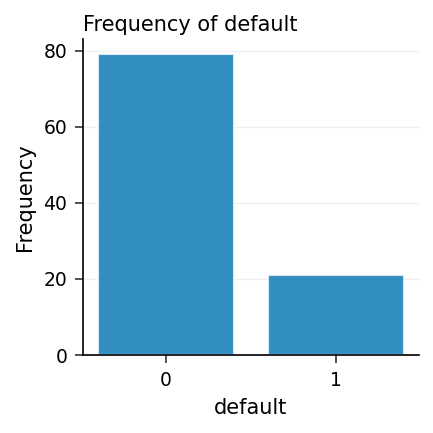

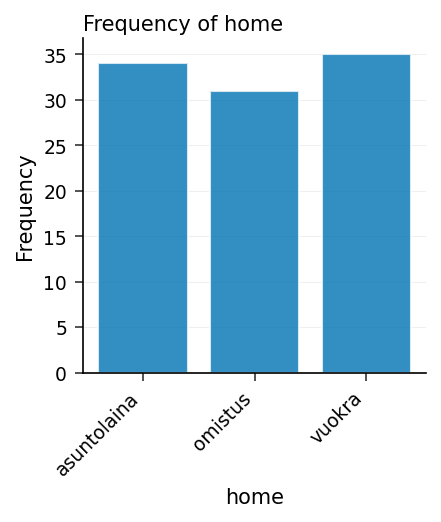

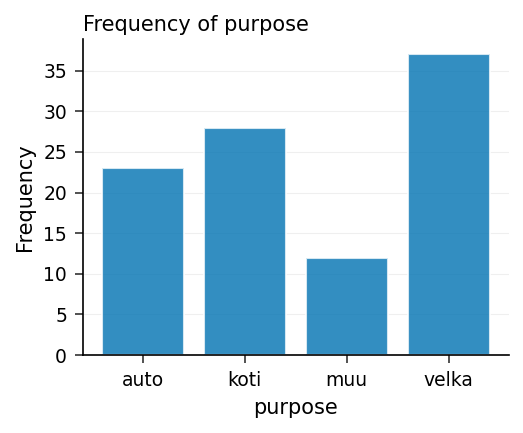

In [1]:
TIEDOT applicants;
   CALL streaminit(20260531);
   PITUUS home $12 purpose $6;
   TEE id = 1 ASTI 100;
      /* Borrower financial profile */
      income      = round(20000 + 80000 * rand('beta', 2, 5), 100);
      loan_amount = round(2000 + 40000 * rand('beta', 2, 4), 100);
      dti         = round(0.05 + 0.55 * rand('beta', 2, 3), 0.001);
      utilization = round(rand('beta', 2, 3), 0.001);
      fico        = round(560 + 280 * rand('beta', 5, 2));
      credit_age  = round(0.5 + 24 * rand('beta', 2, 2), 0.1);
      n_delinq    = rand('poisson', 0.4);

      /* Categorical attributes */
      u = rand('uniform');
      JOS u < 0.34 NIIN home = 'vuokra';
      MUUTEN JOS u < 0.70 NIIN home = 'asuntolaina';
      MUUTEN home = 'omistus';

      v = rand('uniform');
      JOS v < 0.40 NIIN purpose = 'velka';
      MUUTEN JOS v < 0.65 NIIN purpose = 'koti';
      MUUTEN JOS v < 0.85 NIIN purpose = 'auto';
      MUUTEN purpose = 'muu';

      /* Latent default risk: worse DTI/utilization/delinquency and
         lower FICO / shorter history all raise the log-odds. */
      eta = -2.2
            + 3.0 * dti
            + 2.2 * utilization
            - 0.010 * (fico - 680)
            - 0.06 * credit_age
            + 0.55 * n_delinq
            + 0.30 * (home = 'vuokra')
            + 0.25 * (purpose = 'velka');
      p = 1 / (1 + EXP(-eta));
      default = (rand('uniform') < p);

      POISTA u v eta p;
      TULOSTE;
   LOPPU;
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=applicants;
   TABLES default home purpose / nocum;
   NIMIKE default = "Maksukyvyttömyys"
         home    = "Asumismuoto"
         purpose = "Lainan käyttötarkoitus";
SUORITA;

`PROC FREQ`-tuloste vahvistaa epätasapainoisen mutta toimivan maksukyvyttömyysasteen — noin joka viides hakija ajautuu maksukyvyttömäksi (21/100) — ja järkevän jakauman asumismuodon ja lainan käyttötarkoituksen kategorioissa: juuri sellaisen marginaalijakauman, jota odottaisi kuluttajaluototuksen salkussa. Oheiset pylväskaaviot havainnollistavat kunkin marginaalin.

## 2. Pisteytyspuun kasvatus ja karsinta

Mallinnamme muuttujan `default` binäärisenä luokitteluvasteena, nimeten `event='1'`, jotta kaikki herkkyys-/tarkkuus-/AUC-tunnusluvut suuntautuvat *maksukyvyttömyys*-luokkaan. Teemme seuraavaa:

- ilmoitamme kategoriset selittäjät ja vasteen `CLASS`-lauseessa,
- kasvatamme puun **entropia** (informaatiohyöty) -kriteerillä,
- karsimme **kustannuskompleksisuudella** estääksemme puuta muistamasta kohinaa,
- pyydämme **koko puun kaavion** ja **ROC-käyrän**.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Maksukyvyttömyys
  Class variable: Maksukyvyttömyys
  Class variable: Asumismuoto
  Class variable: Lainan käyttötarkoitus
  Predictor variable: Velka/tulo-suhde (DTI)
  Predictor variable: Luottokortin käyttöaste
  Predictor variable: FICO-pisteet
  Predictor variable: Luottohistorian pituus (v)
  Predictor variable: Maksuhäiriöiden lkm
  Predictor variable: Lainan määrä
  Predictor variable: Tulot
  Predictor variable: Asumismuoto
  Predictor variable: Lainan käyttötarkoitus

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Num


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC HPSPLIT data=applicants

NOTE: ODS plot written: HPSplitROCPlot.svg
NOTE: ODS plot written: HPSplitTreePlot.svg
NOTE: PROC HPSPLIT completed.


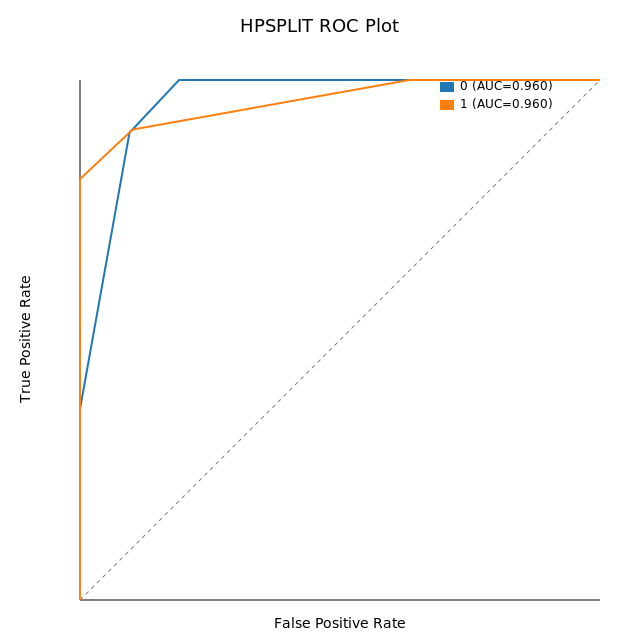

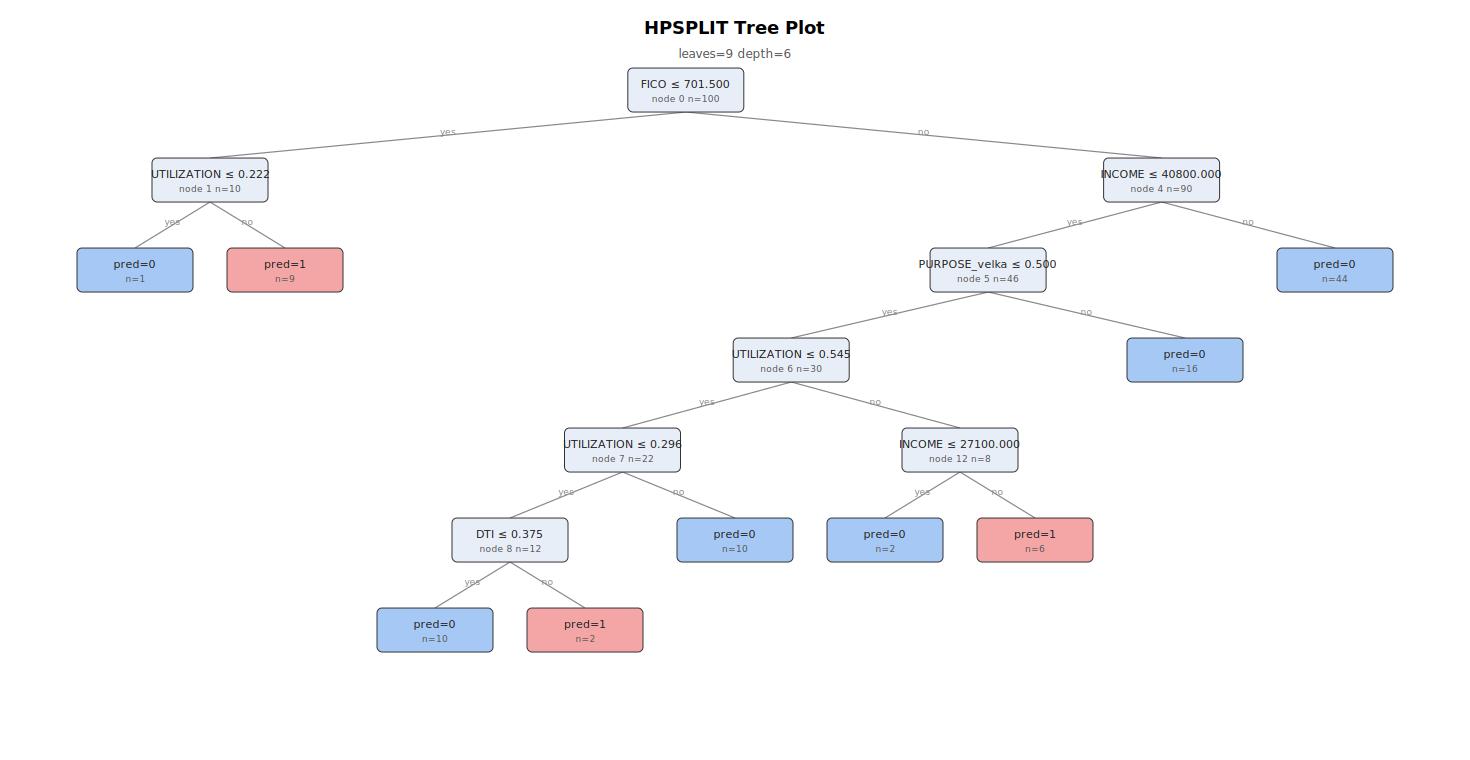

In [2]:
ODS GRAPHICS ON;

PROSEDUURI hpsplit TIEDOT=applicants seed=20260531
             PLOTS=(wholetree roc);
   LUOKKA default home purpose;
   NIMIKE default     = "Maksukyvyttömyys"
         dti         = "Velka/tulo-suhde (DTI)"
         utilization = "Luottokortin käyttöaste"
         fico        = "FICO-pisteet"
         credit_age  = "Luottohistorian pituus (v)"
         n_delinq    = "Maksuhäiriöiden lkm"
         loan_amount = "Lainan määrä"
         income      = "Tulot"
         home        = "Asumismuoto"
         purpose     = "Lainan käyttötarkoitus";
   MODEL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
SUORITA;

**Sovitustunnusluvut** (tarkkuus, virheluokitteluaste, log-häviö) ja **ROC/AUC luokittain** kertovat, kuinka puhtaasti karsittu puu erottaa maksukyvyttömät maksukykyisistä. **Muuttujien tärkeys** -taulukko rankkaisee, mitkä ominaisuudet ohjaavat jakoja — tässä **käyttöaste** ja **FICO** hallitsevat, seuraavana **lainan käyttötarkoitus**, täsmälleen ne vivut, joita luottopolitiikka painottaisi. Alla oleva **koko puun kaavio** esittää valitut jaot solmu-linkki-kaaviona: jokainen sisäsolmu näyttää `ominaisuus ≤ kynnysarvo` -säännön, ja jokainen lehti on väritetty ennustetun luokan mukaan (punainen = ennustettu maksukyvyttömyys, sininen = ennustettu maksukykyisyys) ja merkitty havaintomäärällään.

## 3. Tarkennus ylimpiin jakoihin ja jokaisen hakijan pisteytys

Yllä oleva ROC-käyrä havainnollistaa vaihtokauppaa maksukyvyttömien kiinnisaamisen ja väärien hälytysten välillä; AUC määrittää kokonaisrankkauskyvyn. Seuraavaksi suurennamme puun kaksi ylintä tasoa — informatiivisimmat jaot, jotka analyytikko kääntäisi ylätason luotonmyöntämissäännöiksi — ja tallennamme havaintokohtaiset pisteet tulosaineistoon, jotta voimme auditoida ennusteet myöhemmin.


                                                 The HPSPLIT Procedure                                                  

  Response variable: Maksukyvyttömyys
  Class variable: Maksukyvyttömyys
  Class variable: Asumismuoto
  Class variable: Lainan käyttötarkoitus
  Predictor variable: Velka/tulo-suhde (DTI)
  Predictor variable: Luottokortin käyttöaste
  Predictor variable: FICO-pisteet
  Predictor variable: Luottohistorian pituus (v)
  Predictor variable: Maksuhäiriöiden lkm
  Predictor variable: Lainan määrä
  Predictor variable: Tulot
  Predictor variable: Asumismuoto
  Predictor variable: Lainan käyttötarkoitus

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Num


NOTE: PROC HPSPLIT data=applicants

NOTE: HPSPLIT OUTPUT OUT= dataset written to ./work/8be026e1-bb3f-438e-9e48-9c60e6dedc6d/scored.avro
NOTE: ODS plot written: HPSplitZoomedTree.svg
NOTE: PROC HPSPLIT completed.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


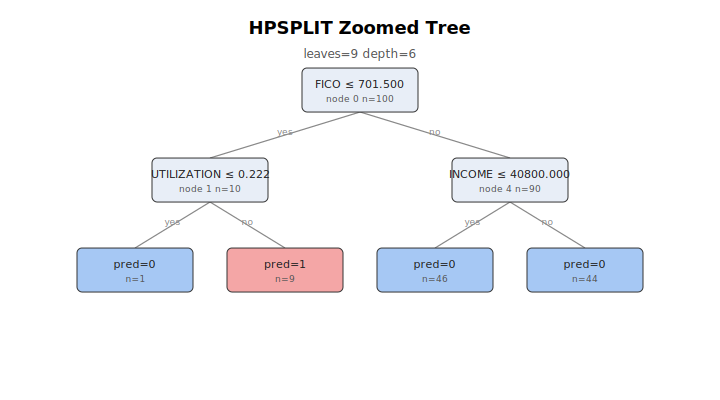

In [3]:
PROSEDUURI hpsplit TIEDOT=applicants seed=20260531
             PLOTS=zoomedtree(nodes=('0') depth=2);
   LUOKKA default home purpose;
   NIMIKE default     = "Maksukyvyttömyys"
         dti         = "Velka/tulo-suhde (DTI)"
         utilization = "Luottokortin käyttöaste"
         fico        = "FICO-pisteet"
         credit_age  = "Luottohistorian pituus (v)"
         n_delinq    = "Maksuhäiriöiden lkm"
         loan_amount = "Lainan määrä"
         income      = "Tulot"
         home        = "Asumismuoto"
         purpose     = "Lainan käyttötarkoitus";
   MODEL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   TULOSTE out=scored;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=scored(obs=10);
   MUUTTUJA p_default1 _node_ _leaf_;
SUORITA;

`zoomedtree`-kaavio suurentaa puun kaksi ylintä tasoa — informatiivisimmat jaot, jotka analyytikko kääntäisi ylätason luotonmyöntämissäännöiksi. `OUTPUT OUT=` -aineisto kuljettaa mukanaan jokaisen hakijan ennustetun maksukyvyttömyystodennäköisyyden (`P_DEFAULT1`) sekä osoitetun solmun ja lehden (`_NODE_`, `_LEAF_`), jotta riski- ja auditointitiimit voivat jäljittää minkä tahansa yksittäisen päätöksen takaisin puun läpi ja rankata hakijat mallinnetun riskin mukaan.

## 4. Käyttöönotettavan pisteytyskoodin vienti

Tulkittavan mallin arvo on siinä, että se voidaan ottaa käyttöön. `CODE FILE=` kirjoittaa itsenäisen DATA-vaiheen — sisäkkäisen `IF/THEN`-jakojen ketjun, joka päättyy ennustettuun maksukyvyttömyystodennäköisyyteen ja luokkaan — joka toistaa puun pisteet mille tahansa uudelle hakemustiedostolle ilman mallipalvelinta.

In [4]:
PROSEDUURI hpsplit TIEDOT=applicants seed=20260531;
   LUOKKA default home purpose;
   NIMIKE default     = "Maksukyvyttömyys"
         dti         = "Velka/tulo-suhde (DTI)"
         utilization = "Luottokortin käyttöaste"
         fico        = "FICO-pisteet"
         credit_age  = "Luottohistorian pituus (v)"
         n_delinq    = "Maksuhäiriöiden lkm"
         loan_amount = "Lainan määrä"
         income      = "Tulot"
         home        = "Asumismuoto"
         purpose     = "Lainan käyttötarkoitus";
   MODEL default (EVENT='1') =
         dti utilization fico credit_age n_delinq
         loan_amount income home purpose;
   grow entropy;
   prune costcomplexity;
   code TIEDOSTO='credit_scorecard.sas';
SUORITA;


                                                 The HPSPLIT Procedure                                                  

  Response variable: Maksukyvyttömyys
  Class variable: Maksukyvyttömyys
  Class variable: Asumismuoto
  Class variable: Lainan käyttötarkoitus
  Predictor variable: Velka/tulo-suhde (DTI)
  Predictor variable: Luottokortin käyttöaste
  Predictor variable: FICO-pisteet
  Predictor variable: Luottohistorian pituus (v)
  Predictor variable: Maksuhäiriöiden lkm
  Predictor variable: Lainan määrä
  Predictor variable: Tulot
  Predictor variable: Asumismuoto
  Predictor variable: Lainan käyttötarkoitus

Model Information
Response Variable         DEFAULT
Event Level               1
Split Criterion           Entropy
Pruning Method            Cost-Complexity
Random Seed               20260531
Number of Observations    100

Predictors
    1. DTI
    2. UTILIZATION
    3. FICO
    4. CREDIT_AGE
    5. N_DELINQ
    6. LOAN_AMOUNT
    7. INCOME
    8. HOME
    9. PURPOSE

Num


NOTE: PROC HPSPLIT data=applicants

NOTE: PROC HPSPLIT completed.


## Tulosten tulkinta

Karsittu entropiapuu antaa riskitiimille kompaktin, auditoitavan luottopisteytyskortin:

- **Jaot koodaavat politiikan.** Hallitsevat jaot — käyttöasteessa ja FICO:ssa, sitten lainan käyttötarkoituksessa ja DTI:ssä — ovat juuri niitä kynnysarvoja, jotka luotonmyöntämistiimi voi nostaa kiinteiksi raja-arvosäännöiksi. Koko puun kaavio esittää jokaisen jakoehdon ja lehden yhdessä kaaviossa.
- **Kustannuskompleksisuuskarsinta** estää puuta muistamasta kohinaa; sovitustunnusluvut (tarkkuus, virheluokitteluaste, log-häviö) tiivistävät, kuinka puhtaasti se erottaa kaksi luokkaa.
- **Muuttujien tärkeys ja ROC/AUC** perustelevat, mitkä ominaisuudet ansaitsevat paikan pisteytyskortissa, ja dokumentoivat sen erottelukyvyn malliriskin hallintaa varten.
- **`CODE FILE=` tekee siitä toiminnallisen** — tuotettu DATA-vaihe pisteyttää uudet hakijat identtisesti tämän ajon kanssa, joten rakennettu malli on täsmälleen se malli, joka otetaan tuotantoon.

Pienellä hakijakannalla puu sovittuu tiukasti koulutusdataan; tuotannossa se kasvatettaisiin koko salkulle, pidettäisiin erillinen validointiosajoukko, kalibroitaisiin todennäköisyyden raja-arvo pankin odotetun tappion taloustieteen mukaan (jäädyn maksukyvyttömyyden kustannus verrattuna hylättyyn hyvään asiakkaaseen) eikä naiivin 0,5:n mukaan, ja puu päivitettäisiin salkun koostumuksen muuttuessa.